# flexible neutrino oscillation simulator 

(c) Isabel Goos, Yael Deniz

15/07/2026



## loading packages

In [1]:
using Pkg
cd(@__DIR__)
Pkg.activate("../")

include("../src/commonBatchs.jl")
include("../src/planet1D.jl")
planet1D.configure_input!()
include("../src/GeoPoints.jl")

using .commonBatchs, .planet1D, .GeoPoints

  Activating project at `~/Documents/Github/flexOPT`


In [2]:
using CairoMakie, LaTeXStrings

In [3]:
include("../src/neutrinoFlux.jl")
using .neutrinoFlux

## local data (every user should control this)

In [4]:
localConfig = joinpath(@__DIR__, "neutrinoPropagation_local.jl")
isfile(localConfig) || error("Copy neutrinoPropagation.config.example.jl to neutrinoPropagation_local.jl and set your local geodynamical files.")
include(localConfig)
all(isfile, geody_files) || error("At least one file configured in neutrinoPropagation_local.jl does not exist.")

true

## constants

## geodynamical models (if we want to)

In [5]:
ρGeodyFile = geody_files.density
compositionGeodyFile = geody_files.composition
temperatureGeodyFile = geody_files.temperature
wGeodyFile = geody_files.water

"/Users/nobuaki/Documents/MantleConvectionTakashi/op_old_full_mars_2025/test_wtr00199"

### binning of energies (binned logarithmically) and cos \theta (binned linearly)

In [6]:
numberEnergyBins = 100
minEnergy = 1.0
maxEnergy = 100.0

numberAngleBins = 100
mincosθ = -1
maxcosθ = 0

binningEnergy = (numberEnergyBins=numberEnergyBins, minEnergy=minEnergy, maxEnergy=maxEnergy)
binningcosθ = (numberAngleBins =numberAngleBins , mincosθ=mincosθ, maxcosθ=maxcosθ)
binning = (energy=binningEnergy, cosθ= binningcosθ)
# makeArrayBins(binningEnergy; option="linear") something like this should be made

# computeFlux(binning) # honda/daemon is already decided by DEFAULT_FLUX_TABLE; 

# maybe computeFlux(binning::this binnning Tuple)  = computeFlux(makeArrayBins(binningEnergy; option="log"))
# or for the custom arrays (energy array, cosarray ) <- bigger than binningArray (6 components)

(energy = (numberEnergyBins = 100, minEnergy = 1.0, maxEnergy = 100.0), cosθ = (numberAngleBins = 100, mincosθ = -1, maxcosθ = 0))

# configurations (Earth model, flux model and detector model)

The background 1D Earth model is configured directly with `planet1D.configure_input!()`.
Use `planet1D.getSet1Dmodel!` to select an Earth, Mars, Moon, or custom model.


Another remark is that I prefer to rotate the virtual Earth based on the north pole definition (if we set detector position as the reference, it might be a bit of tricky for multi-detector situations)

### 1D Earth configuration

In [ ]:
#change_default_flux!(:Honda)

In [7]:
set_default_planet!(:Earth) # :Earth applies WGS84 (otherwise use :SphericalEarth)
configure_input!()
getSet1Dmodel!(:PREM) # PREM is default

Main.planet1D.planet1DPSVmodel(12, 6371.0, 3480.0, ["S", "F", "S", "S", "S", "S", "S", "S", "S", "S", "S", "S"], [0.0, 1221.5, 3480.0, 3630.0, 5600.0, 5701.0, 5771.0, 5971.0, 6151.0, 6291.0, 6346.6, 6356.0], [1221.5, 3480.0, 3630.0, 5600.0, 5701.0, 5771.0, 5971.0, 6151.0, 6291.0, 6346.6, 6356.0, 6371.0], [0.0, 0.19172814314864228, 0.5462250824046461, 0.5697692669910532, 0.8789828912258673, 0.894835975514048, 0.9058232616543713, 0.937215507769581, 0.9654685292732695, 0.9874431015539162, 0.9961701459739445, 0.9976455815413593], [0.19172814314864228, 0.5462250824046461, 0.5697692669910532, 0.8789828912258673, 0.894835975514048, 0.9058232616543713, 0.937215507769581, 0.9654685292732695, 0.9874431015539162, 0.9961701459739445, 0.9976455815413593, 1.0], 0.5462250824046461, [13.0885 0.0 -8.8381 0.0; 12.5815 -1.2638 -3.6426 -5.5281; … ; 2.9 0.0 0.0 0.0; 2.6 0.0 0.0 0.0], [11.2622 0.0 -6.364 0.0; 11.0487 -4.0362 4.8023 -13.5732; … ; 6.8 0.0 0.0 0.0; 5.8 0.0 0.0 0.0], [11.2622 0.0 -6.364 0.0; 11

### detector point 

NB: the detectorPoint's longitude will be ignored if we work with 2D Earth disk (for the sake of rotation)

In [8]:
detectorPoint = GeoPoint(36.296761,15.978403;alt=-2500.0) # lat, lon with altitude in metre KM3NeT ORCA 

GeoPoint(36.296761, 15.978403, -2500.0, [4.94580235816421e6, 1.41616867315421e6, 3.753301731193985e6], 6.368184086710259e6)

### rotation of north poles from real to virtual

In [9]:
northPolePoint = GeoPoint(90.0,0.0) 
northPoleInVirtualEarth = GeoPoint(30.0,0.0) # Another proposition of rotation, if we are working with 2D disk, the longitude should be 0 or 180.0 (which mirrors the disk)

GeoPoint(30.0, 0.0, 0.0, [5.528256639292835e6, 0.0, 3.1703737353836372e6], 6.372824420294012e6)

In [10]:
# Construct a regular 2D Cartesian disk through the real ellipsoidal Earth.
# `centreOfPlanet` keeps the disk origin at the planet centre.
Δx = 5e3 # m
Δz = 5e3 # m
altMin, altMax = -6400e3, 6400e3
horizontalMin, horizontalMax = -6400e3, 6400e3

boxGrids = constructLocalBox(
    northPolePoint,
    Δx,
    Δz,
    altMin,
    altMax,
    horizontalMin,
    horizontalMax;
    centreOption="centreOfPlanet",
    axis_angle_deg=0.0,
)
# axis_angle_deg=0 selects a south-to-north meridional cut.


centreOption = "centreOfPlanet"


(allGridsInGeoPoints = GeoPoint[GeoPoint(-45.13285256600705, 0.0, 2.68353748702893e6, [6.400281423970259e6, 0.0, -6.399718563654286e6], 9.05096679918781e6) GeoPoint(-45.11051581854735, 0.0, 2.6799942971679275e6, [6.400281204102948e6, 0.0, -6.394718563659119e6], 9.047431956085661e6) … GeoPoint(45.11555475214866, 0.0, 2.679996177880436e6, [6.399718783521596e6, 0.0, 6.395281423975092e6], 9.047431956085661e6) GeoPoint(45.13789148106411, 0.0, 2.6835393677375442e6, [6.399718563654286e6, 0.0, 6.400281423970259e6], 9.05096679918781e6); GeoPoint(-45.15529500953442, 0.0, 2.680011010406542e6, [6.395281423975092e6, 0.0, -6.399718783521596e6], 9.047431956085661e6) GeoPoint(-45.13295840683348, 0.0, 2.6764664389688815e6, [6.395281204107782e6, 0.0, -6.394718783526431e6], 9.043895731375944e6) … GeoPoint(45.1379973217458, 0.0, 2.676468319677473e6, [6.39471878352643e6, 0.0, 6.395281204107782e6], 9.043895731375944e6) GeoPoint(45.16033390590276, 0.0, 2.6800128911100887e6, [6.394718563659119e6, 0.0, 6.40028

### Prepare the ellipsoidal seismic model, including real topography

`allGridsInCartesian` remains a regular numerical grid. Topography changes the material assigned to each point, not these coordinates.


In [11]:
topographyPrecisionKm = 5.0
seismicCacheName = "seismicModel2D_topography_$(topographyPrecisionKm)km"
seismicModel = lazyProduceOrLoad(
    seismicCacheName,
    getParamsAndTopo,
    boxGrids.allGridsInGeoPoints,
    copy(boxGrids.effectiveRadii),
    topographyPrecisionKm,
)


Computing seismicModel2D_topography_5.0km


┌ Info: File /Users/nobuaki/Documents/Github/flexOPT/data/topoViaGMT/topoViaGMT_72ead4c3.jld2 does not exist. Producing it now...
└ @ DrWatson /Users/nobuaki/.julia/packages/DrWatson/2QF5p/src/saving_files.jl:106
grdblend [NOTICE]: Remote data courtesy of GMT data server oceania [http://oceania.generic-mapping-tools.org]

grdblend [NOTICE]: SRTM15 Earth Relief v2.7 at 02x02 arc minutes reduced by Gaussian Cartesian filtering (10.5 km fullwidth) [Tozer et al., 2019].
grdblend [NOTICE]:   -> Download 60x60 degree grid tile (earth_relief_02m_g): S90E000
┌ Warning: The Git repository ('/Users/nobuaki/Documents/Github/flexOPT') is dirty! Appending -dirty to the commit ID.
└ @ DrWatson /Users/nobuaki/.julia/packages/DrWatson/2QF5p/src/saving_tools.jl:71
┌ Info: File /Users/nobuaki/Documents/Github/flexOPT/data/topoViaGMT/topoViaGMT_72ead4c3.jld2 saved.
└ @ DrWatson /Users/nobuaki/.julia/packages/DrWatson/2QF5p/src/saving_files.jl:115


(ρ = [0.001 0.001 … 0.001 0.001; 0.001 0.001 … 0.001 0.001; … ; 0.001 0.001 … 0.001 0.001; 0.001 0.001 … 0.001 0.001], Vpv = [0.314 0.314 … 0.314 0.314; 0.314 0.314 … 0.314 0.314; … ; 0.314 0.314 … 0.314 0.314; 0.314 0.314 … 0.314 0.314], Vph = [0.314 0.314 … 0.314 0.314; 0.314 0.314 … 0.314 0.314; … ; 0.314 0.314 … 0.314 0.314; 0.314 0.314 … 0.314 0.314], Vsv = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], Vsh = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], Qμ = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], Qκ = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], QμPower = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], QκPower = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], η = [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0])

### Prepare the virtual spherical-Earth coordinates

`convertedGrids` is useful for geographic diagnostics. `effectiveCoords` is the separate, generally non-separable Cartesian lookup grid used to sample the spherical StagYY model. The regular `boxGrids.allGridsInCartesian` is never replaced.


In [12]:
convertedGrids, rotationAngles = transform_geopoints(
    boxGrids.allGridsInGeoPoints,
    northPolePoint,
    northPoleInVirtualEarth;
    source_planet=:Earth,
    target_planet=:SphericalEarth,
)

newBoxGridsInVirtualEarth = (;
    boxGrids...,
    allGridsInGeoPoints=convertedGrids,
)

effectiveCoords = effective_cartesian_coordinates(
    boxGrids.allGridsInGeoPoints,
    northPolePoint,
    northPoleInVirtualEarth;
    source_planet=:Earth,
    target_planet=:SphericalEarth,
    plane=:xz,
)


(X = [-2.3434954919685153e6 -2.339159969563252e6 … 8.743241526532507e6 8.747585454944743e6; -2.346000167485857e6 -2.341664636115414e6 … 8.740751403808067e6 8.745095334607266e6; … ; -8.745095334607266e6 -8.740751403808067e6 … 2.341664636115414e6 2.346000167485857e6; -8.747585454944743e6 -8.743241526532507e6 … 2.339159969563252e6 2.3434954919685153e6], Y = [-8.74758287122589e6 -8.745069797540985e6 … -2.345994702635578e6 -2.3434961841521235e6; -8.743261893375557e6 -8.740748822107743e6 … -2.3416653277582517e6 -2.3391668003015523e6; … ; 2.3391668003015523e6 2.3416653277582517e6 … 8.740748822107743e6 8.743261893375557e6; 2.3434961841521235e6 2.345994702635578e6 … 8.745069797540985e6 8.74758287122589e6])

In [13]:
# Optional checks for the rotated 2D disk.
@show extrema(p.lon for p in convertedGrids)
@show extrema(p.ecef[2] for p in convertedGrids)
@show rotationAngles.Δθ rotationAngles.Δφ # degrees, for diagnostics
@show rotationAngles.θshift rotationAngles.ϕshift # radians, used by StagYY


extrema((p.lon for p = convertedGrids)) = (0.0, 180.0)
extrema((p.ecef[2] for p = convertedGrids)) = (0.0, 0.0)
rotationAngles.Δθ = 60.00000000000001
rotationAngles.Δφ = 0.0
rotationAngles.θshift = 1.0471975511965979
rotationAngles.ϕshift = 0.0


0.0

In [14]:
# Detector position in the original regular meridional disk.
modifiedLongitude2Disk = 0.0 # use 0.0 or 180.0 for the mirrored disk
@show detectorPointFlat = GeoPoint(
    detectorPoint.lat,
    modifiedLongitude2Disk;
    alt=detectorPoint.alt,
)
detectorLocal = SVector(detectorPointFlat.ecef[1], detectorPointFlat.ecef[3])


detectorPointFlat = GeoPoint(detectorPoint.lat, modifiedLongitude2Disk; alt = detectorPoint.alt) = GeoPoint(36.296761, 0.0, -2500.0, [5.144559716520552e6, 0.0, 3.753301731193985e6], 6.368184086710259e6)


2-element SVector{2, Float64} with indices SOneTo(2):
 5.144559716520552e6
 3.753301731193985e6

#### Regular plotting/solver coordinates

For a 2D model, `allGridsInCartesian` contains `(x,z)` coordinates in metres. For 3D it contains `(x,y,z)`. These coordinates remain regular after creating the separate effective StagYY lookup coordinates.


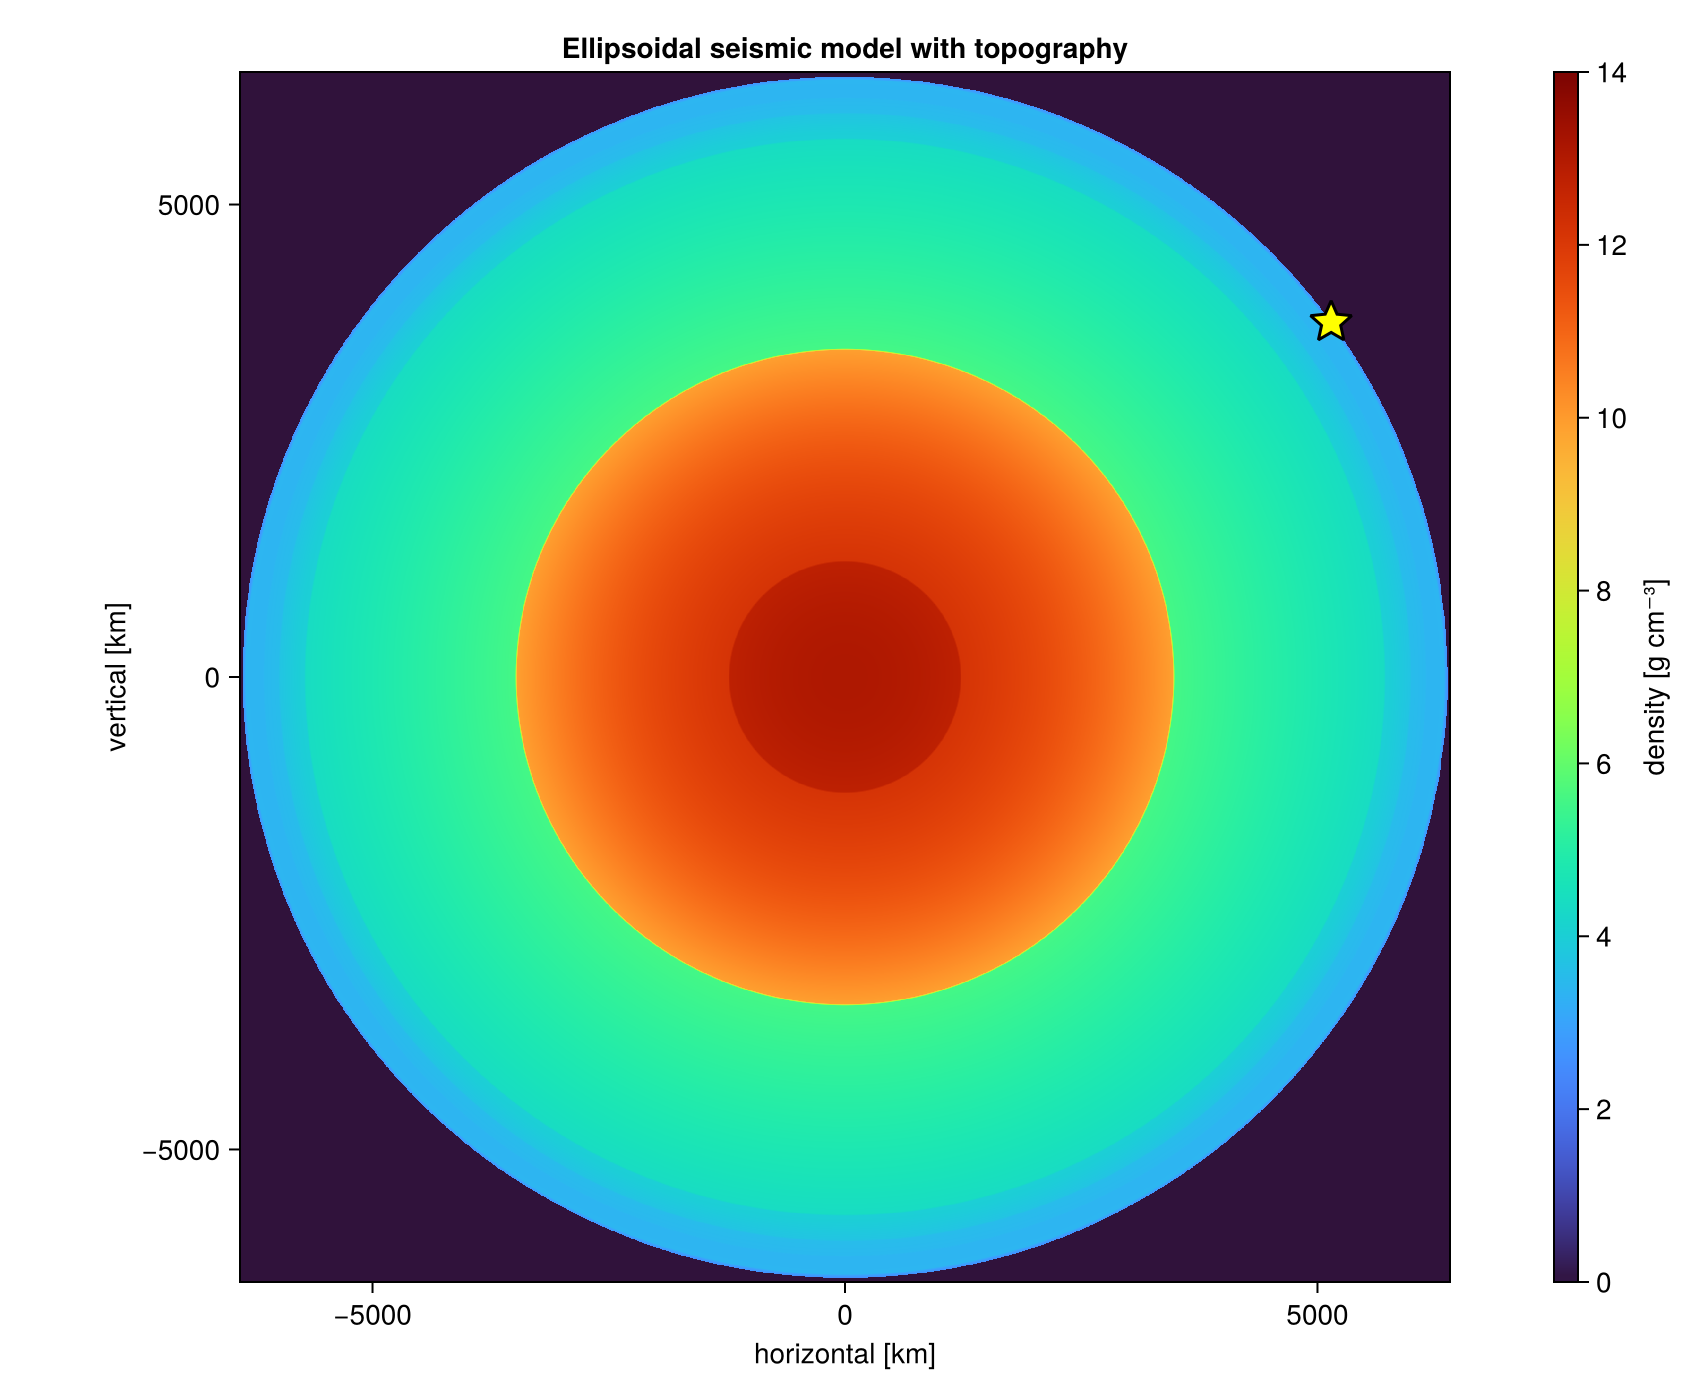

In [15]:
Nx, Nz = size(seismicModel.ρ)
xvals = [p.xz[1] for p in boxGrids.allGridsInCartesian[:, 1]] .* 1e-3
zvals = [p.xz[2] for p in boxGrids.allGridsInCartesian[1, :]] .* 1e-3

figSeismic = Figure(size=(850, 700))
axSeismic = Axis(
    figSeismic[1, 1];
    aspect=DataAspect(),
    xlabel="horizontal [km]",
    ylabel="vertical [km]",
    title="Ellipsoidal seismic model with topography",
)
hmSeismic = heatmap!(
    axSeismic,
    xvals,
    zvals,
    seismicModel.ρ;
    colormap=:turbo,
    colorrange=(0, 14),
)
scatter!(
    axSeismic,
    [detectorLocal[1] * 1e-3],
    [detectorLocal[2] * 1e-3];
    marker=:star5,
    markersize=24,
    color=:yellow,
    strokecolor=:black,
    strokewidth=1.5,
)
Colorbar(figSeismic[1, 2], hmSeismic; label="density [g cm⁻³]")
figSeismic


## Earth model modification (with different 2D/3D images)

### Reading StagYY data (interpolated onto the deformed effective disk)

The DIVAnd analysis-grid dimensions are selected automatically from `correlationLength`: approximately one analysis cell per correlation length in each direction. `max_analysis_points` only caps memory/CPU. The resulting regular DIVAnd analysis is sampled at every point of the non-separable effective grid using threaded bilinear interpolation.


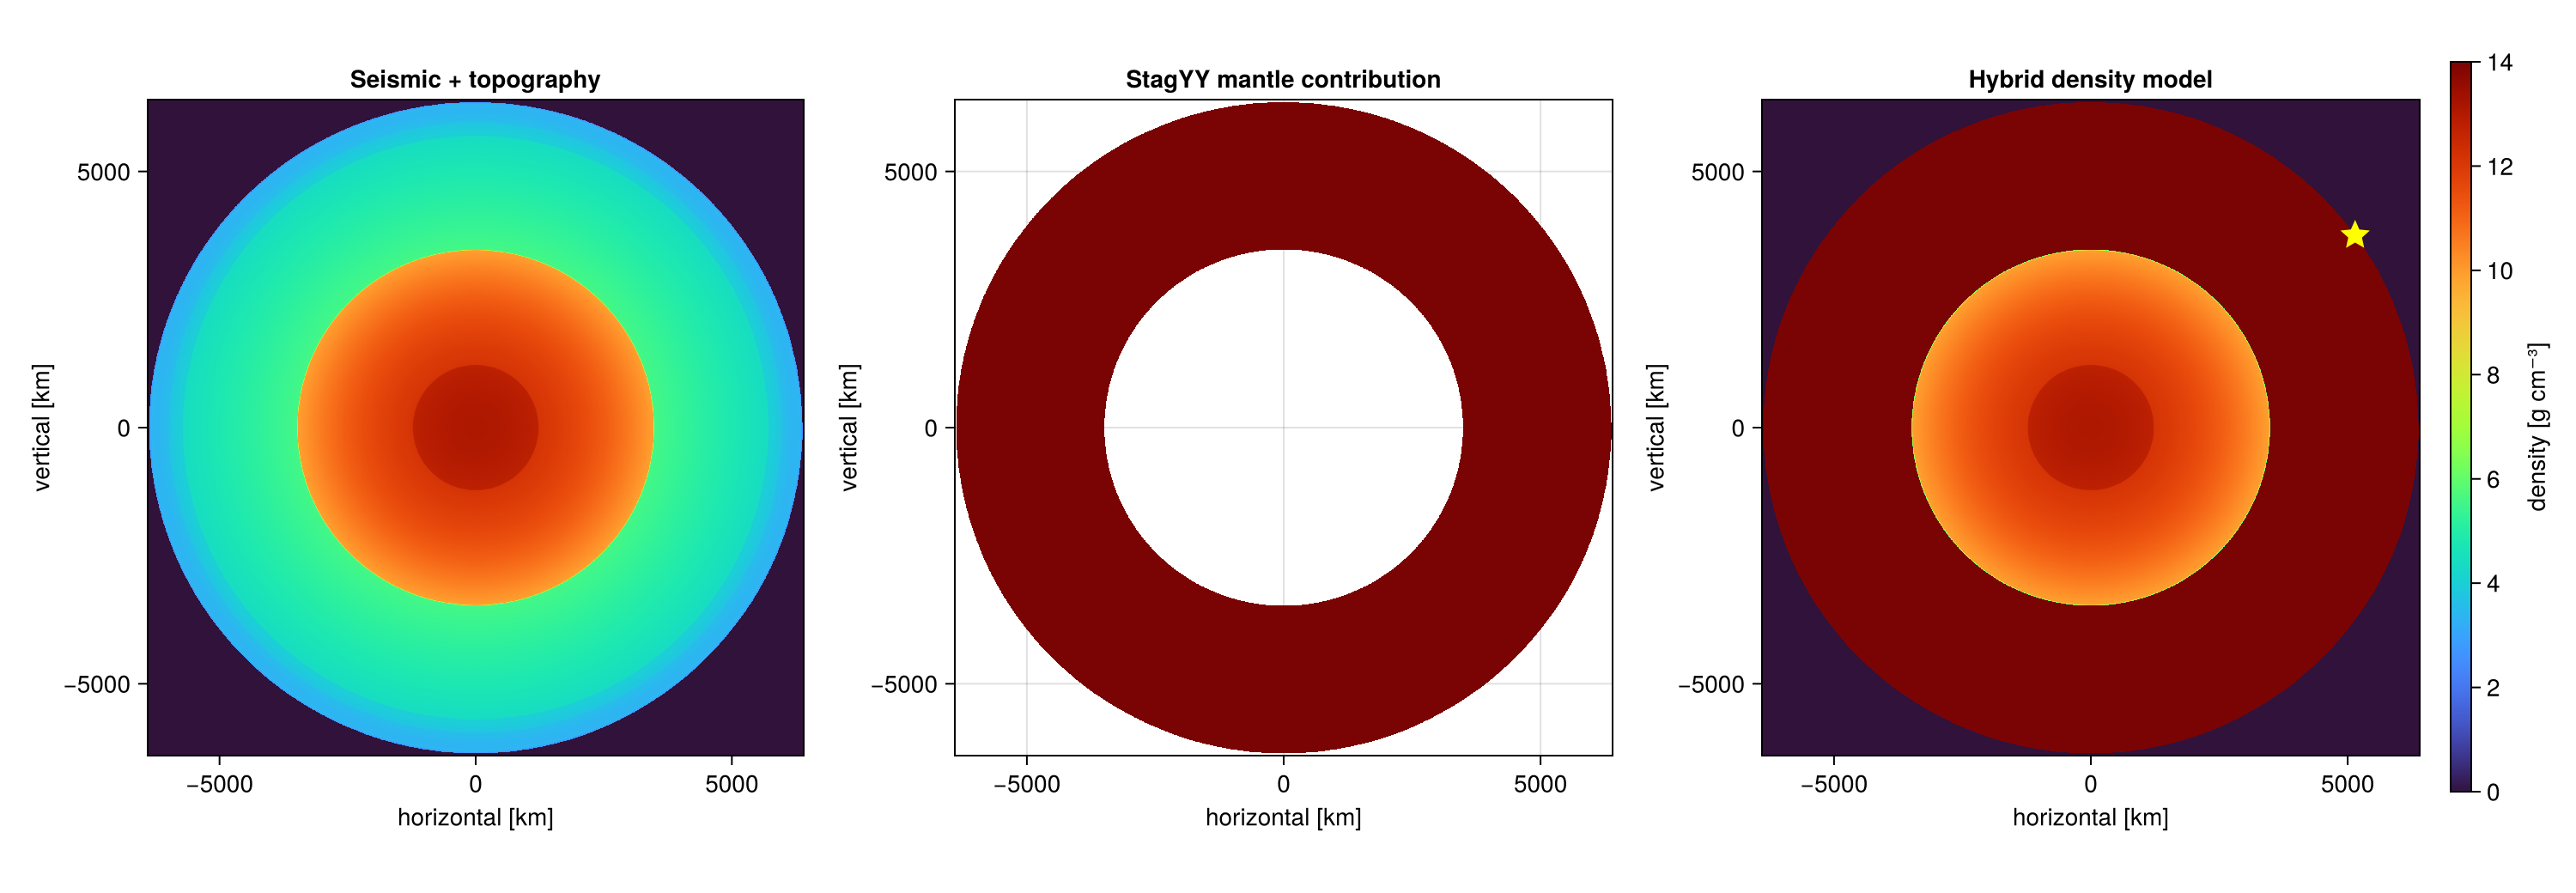

In [ ]:
correlationLength = (20e3, 20e3)

ρCartesian = getCartesianField(
    ρGeodyFile,
    effectiveCoords.X,
    effectiveCoords.Y;
    rotationAngles=rotationAngles,
    correlationLength=correlationLength,
    epsilon2=1.0,
    # analysis_size is automatic from correlationLength
    max_analysis_points=500_000,
    # Extend the outermost spherical StagYY values through positive topography.
    clamp_to_surface=true,
)

# StagYY density files are in kg m⁻³; the seismic model uses g cm⁻³.
stagyyDensityScale = 1e-3
ρStagYY = ρCartesian.field .* stagyyDensityScale

effectiveRadius = hypot.(effectiveCoords.X, effectiveCoords.Y)
solidDensityThreshold = 1.0 # excludes water (1.0) and air (0.001)
stagyyMask = (
    (effectiveRadius .>= ρCartesian.rcmb) .&
    (seismicModel.ρ .> solidDensityThreshold)
)

# Superpose StagYY in the mantle/topographic solid and retain the seismic
# model in the core, water, air, and outside the real topographic surface.
ρHybrid = copy(seismicModel.ρ)
ρHybrid[stagyyMask] .= ρStagYY[stagyyMask]

ρStagYYLayer = fill(NaN, size(ρHybrid))
ρStagYYLayer[stagyyMask] .= ρStagYY[stagyyMask]

figHybrid = Figure(size=(1500, 520))
axes = [
    Axis(figHybrid[1, 1]; aspect=DataAspect(), title="Seismic + topography"),
    Axis(figHybrid[1, 2]; aspect=DataAspect(), title="StagYY mantle contribution"),
    Axis(figHybrid[1, 3]; aspect=DataAspect(), title="Hybrid density model"),
]
fields = (seismicModel.ρ, ρStagYYLayer, ρHybrid)
heatmaps = map(axes, fields) do ax, field
    heatmap!(ax, xvals, zvals, field; colormap=:turbo, colorrange=(0, 14))
end
for ax in axes
    ax.xlabel = "horizontal [km]"
    ax.ylabel = "vertical [km]"
end
scatter!(
    axes[3],
    [detectorLocal[1] * 1e-3],
    [detectorLocal[2] * 1e-3];
    marker=:star5,
    markersize=20,
    color=:yellow,
    strokecolor=:black,
)
Colorbar(figHybrid[1, 4], heatmaps[3]; label="density [g cm⁻³]")
figHybrid


## GeoPoints to make 

### here, i would like the users to decide which flux model to be used


## neutrino flux (completely new!!)


In [ ]:
energies = logrange(minEnergy, maxEnergy, numberEnergyBins)
# read the neutrino-flux table nuflux.csv given in .../Neutrino-Flux/data
bin_centers, flux_νe_interp, flux_νμ_interp, flux_antiνe_interp, flux_antiνμ_interp, energies, flux_νe, flux_νμ, flux_antiνe, flux_antiνμ = read_neutrino_flux_table("nuflux", numberEnergyBins, numberAngleBins, false; data_dir="../dataInput/neutrinoFluxData/")


In [ ]:
 # otherwise it will be daemon flux; this thing should be given in neutrinoFlux/cofig.jl

In [ ]:
# neutrino fluxes look good
# (comparing with Figure 3 in arXiv:1502.03916;
# there are slight differences, especially at low energies, because
# daemonflux is a bit different from honda)

numberEnergyBinSegments = numberEnergyBins - 1 

p1 = plot(energies, (energies.^3) .* sum(flux_νe,     dims=2) ./ numberEnergyBinSegments, label=L"$\nu_e$", 
          xaxis=:log, yaxis=:log, legend=:bottom,
          xlabel="E/GeV", ylabel=L"$\phi \times E_\nu^3$ /(m$^{-2}$s$^{-1}$sr$^{-1}$GeV$^{2}$")
plot!(p1, energies, (energies.^3) .* sum(flux_νμ,     dims=2) ./ numberEnergyBinSegments, label=L"$\nu_\mu$")
plot!(p1, energies, (energies.^3) .* sum(flux_antiνe, dims=2) ./ numberEnergyBinSegments, label=L"$\bar{\nu}_e$")
plot!(p1, energies, (energies.^3) .* sum(flux_antiνμ, dims=2) ./ numberEnergyBinSegments, label=L"$\bar{\nu}_\mu$")


In [ ]:
# linear interpolation on the flux dimension vs. correctly interpolated flux (in log of flux) 
# but anyways, it works (< 0.2%)

# plot the differences between the original and the interpolated fluxes
# to make sure that the interpolation is working correctly
# -> for the original flux we take the mean values
flux_νe_original     = 0.5 .* (sum(flux_νe,     dims=2)[1:end-1] .+ sum(flux_νe, dims=2)[2:end])
flux_νμ_original     = 0.5 .* (sum(flux_νμ,     dims=2)[1:end-1] .+ sum(flux_νμ, dims=2)[2:end])
flux_antiνe_original = 0.5 .* (sum(flux_antiνe, dims=2)[1:end-1] .+ sum(flux_antiνe, dims=2)[2:end])
flux_antiνμ_original = 0.5 .* (sum(flux_antiνμ, dims=2)[1:end-1] .+ sum(flux_antiνμ, dims=2)[2:end])
p2 = plot(bin_centers, 100 .* (sum(flux_νe_interp, dims=2) .- flux_νe_original) ./ flux_νe_original, 
          label=L"$\nu_e$", xlabel="E/GeV", ylabel="100 * (original - interpolation) / interpolation")
plot!(p2, bin_centers, 100 .* (sum(flux_νμ_interp,     dims=2) .- flux_νμ_original)     ./ flux_νμ_original,     label=L"$\nu_\mu$") 
plot!(p2, bin_centers, 100 .* (sum(flux_antiνe_interp, dims=2) .- flux_antiνe_original) ./ flux_antiνe_original, label=L"$\bar{\nu}_e$") 
plot!(p2, bin_centers, 100 .* (sum(flux_antiνμ_interp, dims=2) .- flux_antiνμ_original) ./ flux_antiνμ_original, label=L"$\bar{\nu}_\mu$") 


In [ ]:
size(flux_νe)

# i don't touch the pb of reverse(')

In [ ]:

# This is what we need to compute the interacting events!:
# TO-DO: put this computation in the function, no user should be doing this XD
flux_νe = reverse(flux_νe', dims=1)
flux_νμ = reverse(flux_νμ', dims=1)
flux_antiνe = reverse(flux_antiνe', dims=1)
flux_antiνμ = reverse(flux_antiνμ', dims=1)

In [ ]:
# neutrino oscillation probabilities look good
# TO-DO: Paνe2aντ deserves some attention → do a difference with OscProb!
minX, maxX, nX = -6500e3, 6500e3, 521
n_angles  = 100
n_pts     = 100
zposition = 2.5e3
energy_min = 1.0
energy_max = 100.0
energy_max = 40.0
osc_probs_nu, osc_probs_antinu = Neutrino_Oscillations.produce_neutrino_oscillation_probabilities(minX, maxX, nX, n_angles, n_pts, zposition, energy_min=energy_min, energy_max=energy_max)
# neutrinos, NMO
Pνe2νe = osc_probs_nu[:, :, 1, 1]' 
Pνe2νμ = osc_probs_nu[:, :, 1, 2]' 
Pνe2ντ = osc_probs_nu[:, :, 1, 3]' 
Pνμ2νe = osc_probs_nu[:, :, 2, 1]' 
Pνμ2νμ = osc_probs_nu[:, :, 2, 2]' 
Pνμ2ντ = osc_probs_nu[:, :, 2, 3]' 
# antineutrinos, NMO
Paνe2aνe = osc_probs_antinu[:, :, 1, 1]' 
Paνe2aνμ = osc_probs_antinu[:, :, 1, 2]' 
Paνe2aντ = osc_probs_antinu[:, :, 1, 3]' 
Paνμ2aνe = osc_probs_antinu[:, :, 2, 1]' 
Paνμ2aνμ = osc_probs_antinu[:, :, 2, 2]' 
Paνμ2aντ = osc_probs_antinu[:, :, 2, 3]' 

# plots for neutrinos, NMO
angles = range(-1, 0, length=100)
titles = (
    L"P($\nu_e \rightarrow \nu_e$)", L"P($\nu_e \rightarrow \nu_\mu$)", L"P($\nu_e \rightarrow \nu_\tau$)",
    L"P($\nu_\mu \rightarrow \nu_e$)", L"P($\nu_\mu \rightarrow \nu_\mu$)", L"P($\nu_\mu \rightarrow \nu_\tau$)"
)
all_probs = (
    Pνe2νe, Pνe2νμ, Pνe2ντ,
    Pνμ2νe, Pνμ2νμ, Pνμ2ντ
)
plot_list = []
for idx in 1:6
    # determine grid positions for labels
    is_bottom_row = idx > 3
    is_left_column = (idx == 1 || idx == 4)
    is_right_column = (idx ==3 || idx == 6)
    p = heatmap(
        energies, angles, all_probs[idx],              
        title = titles[idx],
        xlabel = is_bottom_row ? "Energy/GeV" : "",
        ylabel = is_left_column ? L"\cos\theta" : "",
        colorbar_title = is_right_column ? "Oscillation probability" : "",
        xscale = :log10,
        clim = (0, 1),
        cmap = :viridis
    )
    push!(plot_list, p)
end
final_plot = plot(
    plot_list..., 
    layout = (2, 3), 
    size = (1000, 400), 
    margin = 1Plots.mm,
)

# plots for antineutrinos, NMO
titles = (
    L"P($\bar{\nu}_e \rightarrow \bar{\nu}_e$)", L"P($\bar{\nu}_e \rightarrow \bar{\nu}_\mu$)", L"P($\bar{\nu}_e \rightarrow \bar{\nu}_\tau$)",
    L"P($\bar{\nu}_\mu \rightarrow \bar{\nu}_e$)", L"P($\bar{\nu}_\mu \rightarrow \bar{\nu}_\mu$)", L"P($\bar{\nu}_\mu \rightarrow \bar{nu}_\tau$)"
)
all_probs = (
    Paνe2aνe, Paνe2aνμ, Paνe2aντ,
    Paνμ2aνe, Paνμ2aνμ, Paνμ2aντ
)
plot_list = []
for idx in 1:6
    # determine grid positions for labels
    is_bottom_row = idx > 3
    is_left_column = (idx == 1 || idx == 4)
    is_right_column = (idx ==3 || idx == 6)
    p = heatmap(
        energies, angles, all_probs[idx],              
        title = titles[idx],
        xlabel = is_bottom_row ? "Energy/GeV" : "",
        ylabel = is_left_column ? L"\cos\theta" : "",
        colorbar_title = is_right_column ? "Oscillation probability" : "",
        xscale = :log10,
        clim = (0, 1),
        cmap = :viridis
    )
    push!(plot_list, p)
end
final_plot = plot(
    plot_list..., 
    layout = (2, 3), 
    size = (1000, 400), 
    margin = 1Plots.mm
)
